In [5]:
import pandas as pd

df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Attrition'].value_counts())

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

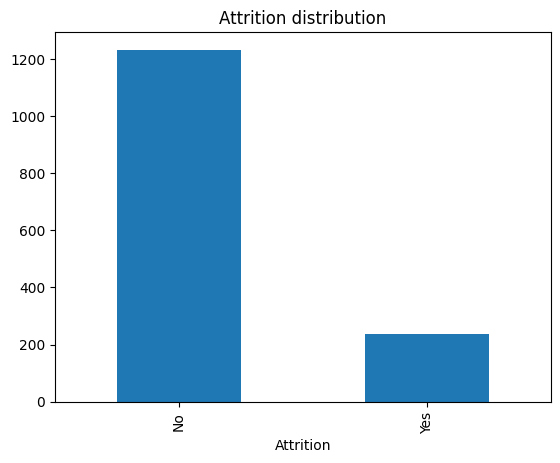

In [10]:
#Target Distribution
df['Attrition'].value_counts().plot(kind='bar')
plt.title('Attrition distribution')
plt.savefig('attrition_dist.png')

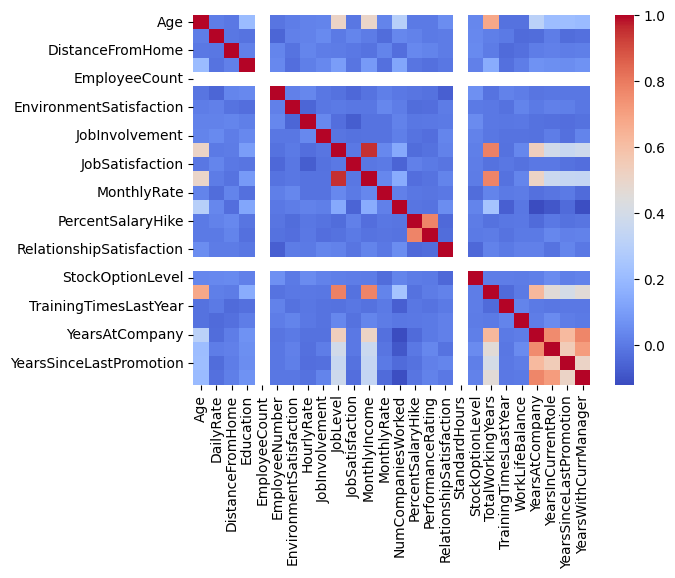

In [11]:
#Correlation heatmap(numerical coloumns only)
numeric_df=df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),cmap='coolwarm',annot=False)
plt.savefig('correlation_heatmap.png')

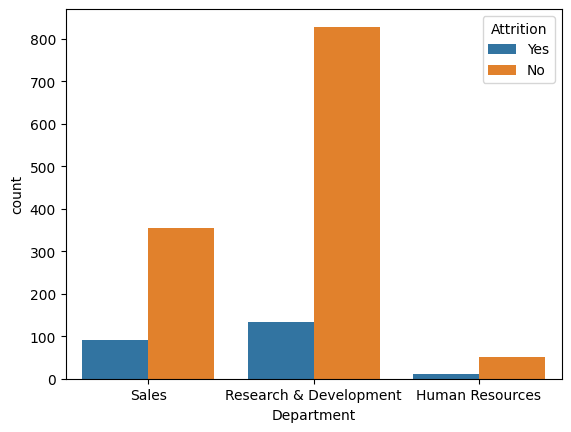

In [13]:
#Attrition by department
sns.countplot(data=df,x='Department',hue='Attrition')
plt.savefig('attrition_by_dept.png')

In [15]:
from sklearn.model_selection import train_test_split

#Encode target:yes=1 and no=0
df['Attrition']=df['Attrition'].map({'Yes':1,'No':0})

#drop coloumns with no predictive value
df.drop(['EmployeeCount','Over18','StandardHours','EmployeeNumber'],axis=1,inplace=True)

X=df.drop('Attrition',axis=1)
y=df['Attrition']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

#Identify coloumn types 
categorical_cols=X.select_dtypes(include='object').columns.tolist()
numerical_cols=X.select_dtypes(include='number').columns.tolist()

#preprocessing for numerical features
num_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

#preprocessing for categorical features
cat_transformer=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

#Combine into one ColumnTransformer
preprocessor=ColumnTransformer([
    ('num',num_transformer,numerical_cols),
    ('cat',cat_transformer,categorical_cols)
])

In [29]:
import mlflow
import mlflow.sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import numpy as np

scale = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'logistic_regression': LogisticRegression(
        max_iter=2000, C=0.5, random_state=42,
        class_weight='balanced', solver='liblinear'
    ),

    'random_forest': RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight='balanced'
    ),

    'xgboost': XGBClassifier(
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=42,
        max_depth=4,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8
    )
}

best_model = None
best_f1 = 0
best_threshold = 0

mlflow.set_tracking_uri("file:///C:/Users/Saniya Bonde/mlruns")
mlflow.set_experiment('employee_attrition')

for name, model in models.items():
    with mlflow.start_run(run_name=name):

        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # Train
        full_pipeline.fit(X_train, y_train)

        # Probabilities
        y_prob = full_pipeline.predict_proba(X_test)[:, 1]

        # 🔥 THRESHOLD TUNING
        thresholds = np.arange(0.1, 0.9, 0.02)

        best_thresh_local = 0
        best_f1_local = 0

        for t in thresholds:
            y_pred_t = (y_prob >= t).astype(int)
            f1_temp = f1_score(y_test, y_pred_t)

            if f1_temp > best_f1_local:
                best_f1_local = f1_temp
                best_thresh_local = t

        # ✅ Final prediction using best threshold
        y_pred = (y_prob >= best_thresh_local).astype(int)

        # Metrics
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        # Logging
        mlflow.log_metric('f1_score', f1)
        mlflow.log_metric('roc_auc', roc_auc)
        mlflow.log_param('threshold', best_thresh_local)
        mlflow.sklearn.log_model(full_pipeline, 'model')

        print(f"{name}: Best Threshold={best_thresh_local:.2f}, F1={f1:.3f}, ROC-AUC={roc_auc:.3f}")
        print(classification_report(y_test, y_pred))

        # Track best model
        if f1 > best_f1:
            best_f1 = f1
            best_model = full_pipeline
            best_threshold = best_thresh_local

2026/03/25 16:37:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 16:37:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


logistic_regression: Best Threshold=0.62, F1=0.524, ROC-AUC=0.807
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       247
           1       0.48      0.57      0.52        47

    accuracy                           0.83       294
   macro avg       0.70      0.73      0.71       294
weighted avg       0.85      0.83      0.84       294



2026/03/25 16:37:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 16:37:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


random_forest: Best Threshold=0.16, F1=0.486, ROC-AUC=0.788
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       247
           1       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294



2026/03/25 16:37:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 16:38:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


xgboost: Best Threshold=0.48, F1=0.465, ROC-AUC=0.766
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       247
           1       0.51      0.43      0.47        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.69       294
weighted avg       0.83      0.84      0.84       294



In [31]:
import joblib

joblib.dump({
    'model': best_model,
    'threshold': best_threshold
}, 'best_model.pkl')

print(f'Best model with F1: {best_f1:.3f}')
print(f'Best threshold: {best_threshold:.2f}')

Best model with F1: 0.524
Best threshold: 0.62
